#### ============================================================
# 03 Exploratory Data Analysis
## Melbourne Metro Rail Patronage Analytics Project
#### ============================================================

##### This notebook explores Melbourne metropolitan train station patronage
##### between 2018–2019 and 2024–2025.
#####
##### Main goals:
1. Understand network-level patronage trends
2. Identify busiest and lowest-use stations
3. Analyse COVID impact and recovery
4. Explore weekday/weekend and peak-period behaviour
5. Generate insights for SQL analysis and Power BI dashboarding

## Data Source

Source:
Victorian Government Open Data Portal

Coverage:
FY2018–19 to FY2024–25

Stations:
222–223 metropolitan stations per year

Measures:
Annual patronage, weekday demand, weekend demand, peak-period demand, station location.

In [15]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

In [3]:
# Set Project Paths
PROJECT_ROOT = Path("..")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

MASTER_DATA_FILE = PROCESSED_DATA_DIR / "train_patronage_master.csv"


In [4]:
# Load Master Data
master_df = pd.read_csv(MASTER_DATA_FILE)

master_df.head()

,financial_year,stop_id,stop_name,stop_lat,stop_long,pax_annual,pax_weekday,pax_norm_weekday,pax_sch_hol_weekday,pax_saturday,pax_sunday,pax_pre_am_peak,pax_am_peak,pax_interpeak,pax_pm_peak,pax_pm_late
0,2018-2019,19827,Stony Point,-38.374235,145.221837,5400,50,50,50,50,50,50,50,50,50,50
1,2018-2019,19828,Crib Point,-38.366123,145.204043,17900,50,50,50,150,100,50,50,50,50,50
2,2018-2019,19829,Morradoo,-38.354033,145.189603,5650,50,50,50,50,50,50,50,50,50,50
3,2018-2019,19830,Bittern,-38.337390,145.178026,14800,50,50,50,50,50,50,50,50,50,50
4,2018-2019,19831,Hastings,-38.305659,145.185980,21900,50,50,50,50,50,50,50,50,50,50


In [5]:
# Check dataset dimensions
master_df.shape

(1555, 16)

In [6]:
# Review column names
master_df.columns.tolist()

['financial_year',
 'stop_id',
 'stop_name',
 'stop_lat',
 'stop_long',
 'pax_annual',
 'pax_weekday',
 'pax_norm_weekday',
 'pax_sch_hol_weekday',
 'pax_saturday',
 'pax_sunday',
 'pax_pre_am_peak',
 'pax_am_peak',
 'pax_interpeak',
 'pax_pm_peak',
 'pax_pm_late']

In [7]:
# Review data types and missing values
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1555 entries, 0 to 1554
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   financial_year       1555 non-null   str    
 1   stop_id              1555 non-null   int64  
 2   stop_name            1555 non-null   str    
 3   stop_lat             1555 non-null   float64
 4   stop_long            1555 non-null   float64
 5   pax_annual           1555 non-null   int64  
 6   pax_weekday          1555 non-null   int64  
 7   pax_norm_weekday     1555 non-null   int64  
 8   pax_sch_hol_weekday  1555 non-null   int64  
 9   pax_saturday         1555 non-null   int64  
 10  pax_sunday           1555 non-null   int64  
 11  pax_pre_am_peak      1555 non-null   int64  
 12  pax_am_peak          1555 non-null   int64  
 13  pax_interpeak        1555 non-null   int64  
 14  pax_pm_peak          1555 non-null   int64  
 15  pax_pm_late          1555 non-null   int64  
dtyp

In [8]:
# Checking missing values by columns
missing_values = (
    master_df
    .isna()
    .sum()
    .reset_index()
)
missing_values.columns = ["column", "missing_count"]

missing_values.sort_values("missing_count", ascending=False)

,column,missing_count
0,financial_year,0
1,stop_id,0
2,stop_name,0
3,stop_lat,0
4,stop_long,0
5,pax_annual,0
6,pax_weekday,0
7,pax_norm_weekday,0
8,pax_sch_hol_weekday,0
9,pax_saturday,0


In [9]:
# Check duplicated values
master_df.duplicated().sum()

np.int64(0)

In [10]:
# Define key years used throughout the analysis

PRE_COVID_YEAR = "2018-2019"
COVID_YEAR = "2020-2021"
RECOVERY_YEAR = "2024-2025"

# Define key columns

YEAR_COL = "financial_year"
STATION_COL = "stop_name"
PATRONAGE_COL = "pax_annual"

### Analysis 1 — Network Patronage Trend

In [11]:
# Business Question:
# How has overall passenger demand changed across the Melbourne rail network?

network_patronage = (
    master_df
    .groupby("financial_year")["pax_annual"]
    .sum()
    .reset_index()
)

network_patronage

,financial_year,pax_annual
0,2018-2019,231607950
1,2019-2020,178626800
2,2020-2021,77820000
3,2021-2022,94736800
4,2022-2023,149195750
5,2023-2024,173839400
6,2024-2025,178480700


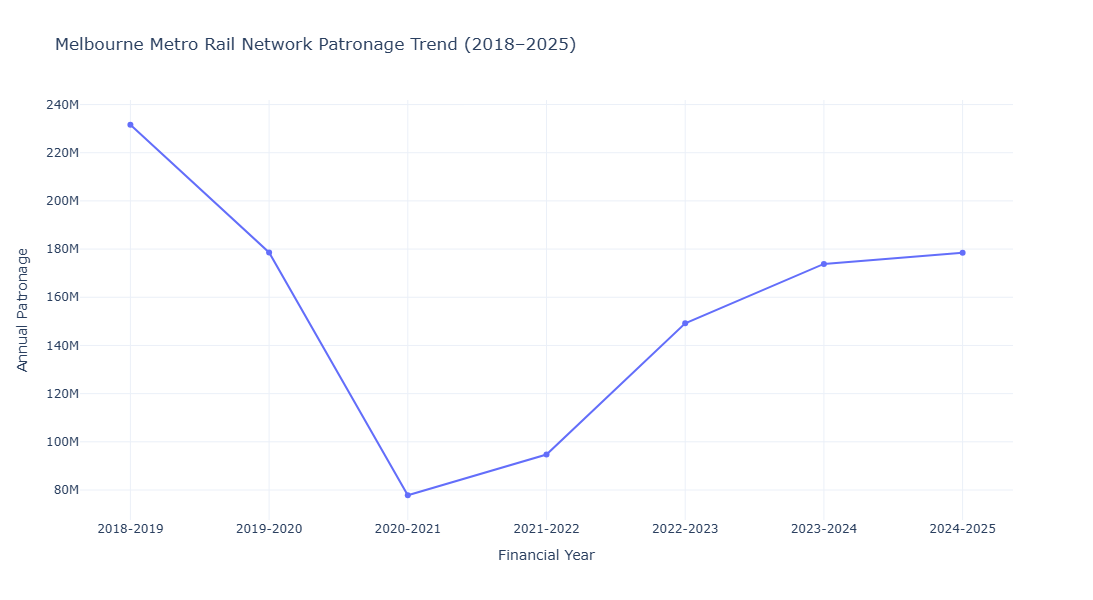

In [19]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=network_patronage[YEAR_COL],
        y=network_patronage[PATRONAGE_COL],
        mode="lines+markers",
        name="Patronage"
    )
)

fig.update_layout(
    title="Melbourne Metro Rail Network Patronage Trend (2018–2025)",
    xaxis_title="Financial Year",
    yaxis_title="Annual Patronage",
    template="plotly_white",
    hovermode="x unified",
    height=600
)

fig.show()

### Observation

Melbourne's metropolitan rail network experienced a significant decline in annual patronage during the COVID-19 period, with patronage reaching its lowest level in 2020–2021.

Following the pandemic, patronage showed a steady recovery trend across subsequent financial years. However, by 2024–2025, total network patronage remained below the pre-pandemic level recorded in 2018–2019.

This suggests that while passenger demand has recovered substantially, the network has not yet fully returned to historical usage levels. Potential contributing factors may include changes in commuting behaviour, increased adoption of hybrid working arrangements, and shifts in travel patterns following the pandemic.

A limitation of the analysis is the availability of only one pre-COVID baseline year (2018–2019). Additional historical data from earlier years would provide greater confidence in understanding long-term patronage trends and determining whether the pre-pandemic level represented typical network demand or part of a broader growth trend.

### Business Insight

The continued gap between current patronage and pre-pandemic levels may indicate a structural change in travel behaviour rather than a temporary disruption. Transport planners may need to reassess long-term demand forecasts and service planning assumptions to reflect evolving commuter patterns.

In [22]:
# Calculate annual percentage change in total network patronage

network_patronage["previous_year_patronage"] = (
    network_patronage[PATRONAGE_COL].shift(1)
)

network_patronage["yoy_growth_pct"] = (
    (
        network_patronage[PATRONAGE_COL]
        - network_patronage["previous_year_patronage"]
    )
    / network_patronage["previous_year_patronage"]
    * 100
).round(2)

network_patronage

,financial_year,pax_annual,previous_year_patronage,yoy_growth_pct
0,2018-2019,231607950,NaN,NaN
1,2019-2020,178626800,231607950.0,-22.88
2,2020-2021,77820000,178626800.0,-56.43
3,2021-2022,94736800,77820000.0,21.74
4,2022-2023,149195750,94736800.0,57.48
5,2023-2024,173839400,149195750.0,16.52
6,2024-2025,178480700,173839400.0,2.67


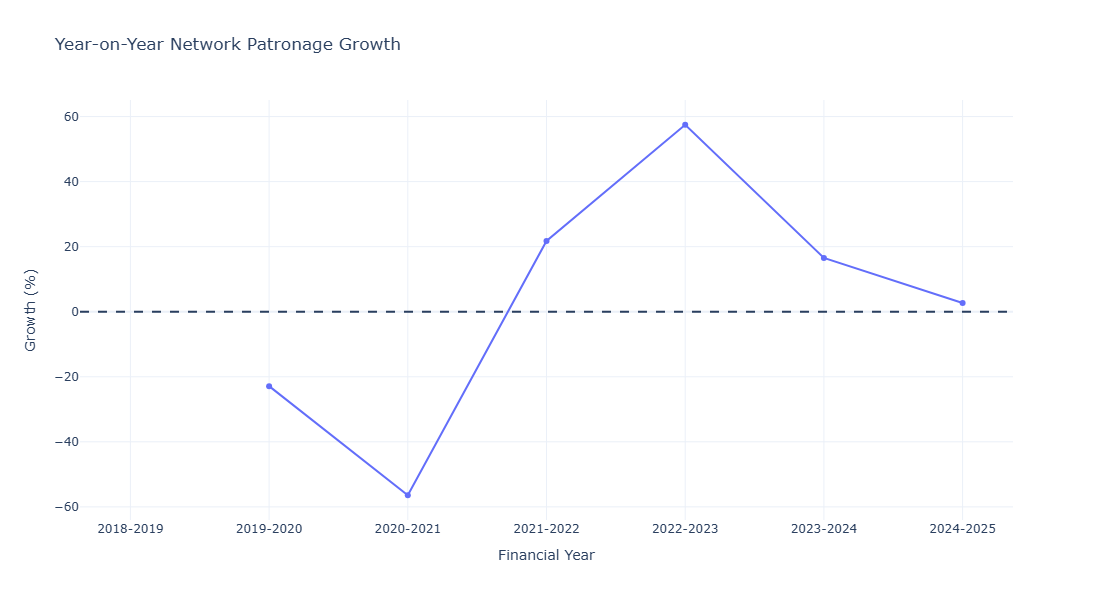

In [27]:
fig_1 = go.Figure()

fig_1.add_trace(
    go.Scatter(
        x=network_patronage["financial_year"],
        y=network_patronage["yoy_growth_pct"],
        mode="lines+markers",
        name="YoY Growth (%)"
    )
)

fig_1.update_layout(
    title="Year-on-Year Network Patronage Growth",
    xaxis_title="Financial Year",
    yaxis_title="Growth (%)",
    template="plotly_white",
    hovermode="x unified",
    height=600
)

fig_1.add_hline(
    y=0,
    line_dash="dash"
)

fig_1.show()

### Observation

The Melbourne metropolitan rail network experienced two consecutive years of negative growth during the COVID-19 period, with the largest decline occurring in 2020–2021 when patronage fell by approximately 56% compared to the previous year.

Following the pandemic, passenger demand recovered strongly, with growth peaking at approximately 57% in 2022–2023. However, the rate of growth subsequently slowed to around 17% in 2023–2024 and approximately 3% in 2024–2025.

This pattern suggests that while patronage recovery remains positive, growth is stabilising and the network may be approaching a new post-pandemic equilibrium.

### Analysis 2 — Identifying busiest and lowest-use stations

In [41]:
# Top 10 busiest stations
busiest_stations = (
    master_df
    .groupby("stop_name")
    .agg(
        pax_annual=("pax_annual", "sum"),
        stop_lat=("stop_lat", "first"),
        stop_long=("stop_long", "first")
    )
    .reset_index()
    .sort_values("pax_annual", ascending=False)
    .head(10)
)

busiest_stations

,stop_name,pax_annual,stop_lat,stop_long
71,Flinders Street,128516900,-37.818305,144.966964
186,Southern Cross,84848350,-37.817936,144.951411
123,Melbourne Central,67494150,-37.809939,144.962593
159,Parliament,39826900,-37.811054,144.972911
72,Footscray,26917450,-37.801083,144.903199
68,Flagstaff,21436800,-37.811981,144.955654
166,Richmond,20992950,-37.824074,144.990164
185,South Yarra,20254550,-37.838449,144.992342
35,Caulfield,19056250,-37.877459,145.042525
24,Box Hill,16148500,-37.819222,145.121429


Flinders Street was the busiest station across the study period, recording approximately 128 million passenger movements between 2018–2019 and 2024–2025.

The results are dominated by major CBD and interchange stations including Southern Cross, Melbourne Central, Parliament, and Richmond, reflecting their importance as key destinations and transfer hubs within Melbourne's metropolitan rail network.

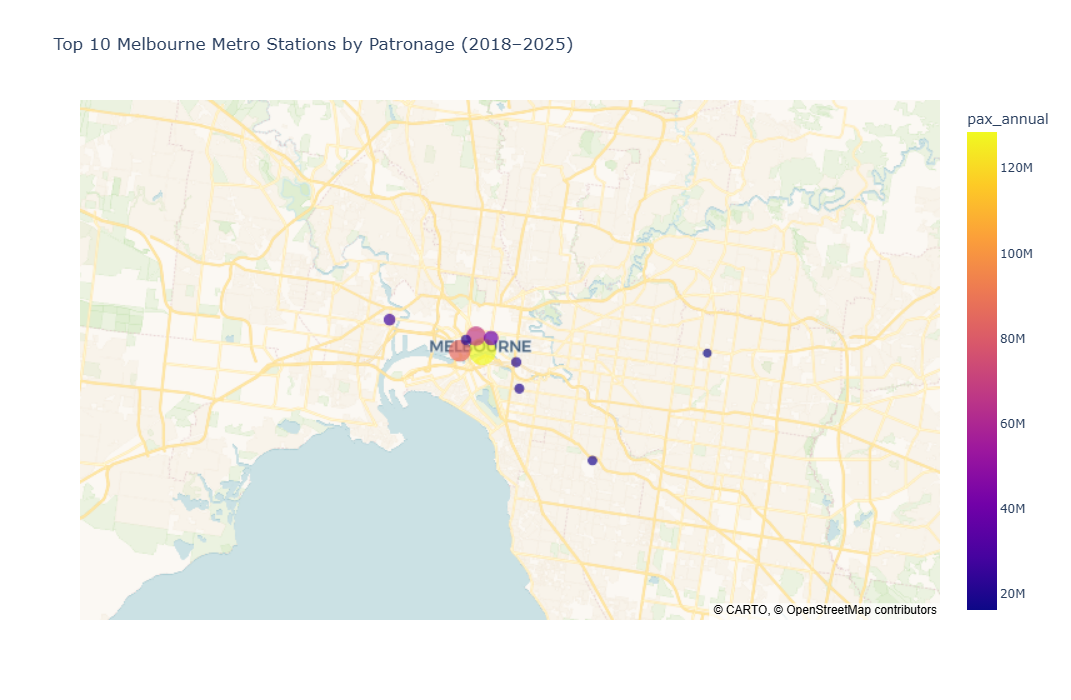

In [43]:
fig = px.scatter_map(
    busiest_stations,
    lat="stop_lat",
    lon="stop_long",
    size="pax_annual",
    color="pax_annual",
    hover_name="stop_name",
    hover_data={
        "pax_annual": ":,",
        "stop_lat": False,
        "stop_long": False
    },
    zoom=10,
    height=700,
    title="Top 10 Melbourne Metro Stations by Patronage (2018–2025)"
)

fig.show()

### Observation

The geographic map shows that the highest-patronage stations are strongly concentrated around Melbourne's CBD and major interchange locations. Flinders Street, Southern Cross, Melbourne Central and Parliament form a clear central demand cluster, while stations such as Footscray, Richmond, Caulfield and Box Hill reflect important suburban or interchange demand points.

This suggests that network patronage is heavily influenced by central business district access, interchange connectivity, and major activity centres.

In [44]:
# Bottom 10  stations
bottom_10_stations  = (
    master_df
    .groupby("stop_name")
    .agg(
        pax_annual=("pax_annual", "sum"),
        stop_lat=("stop_lat", "first"),
        stop_long=("stop_long", "first")
    )
    .reset_index()
    .sort_values("pax_annual", ascending=True)
    .head(10)
)

bottom_10_stations

,stop_name,pax_annual,stop_lat,stop_long
13,Baxter,15950,-38.194043,145.160526
140,Morradoo,24300,-38.354033,145.189603
203,Tyabb,25050,-38.259815,145.186401
191,Stony Point,36400,-38.374235,145.221837
115,Leawarra,41600,-38.152034,145.139534
182,Somerville,54250,-38.225342,145.176245
20,Bittern,57850,-38.337390,145.178026
58,East Pakenham,58200,-38.084284,145.506311
46,Crib Point,68350,-38.366123,145.204043
88,Hastings,93200,-38.305659,145.185980


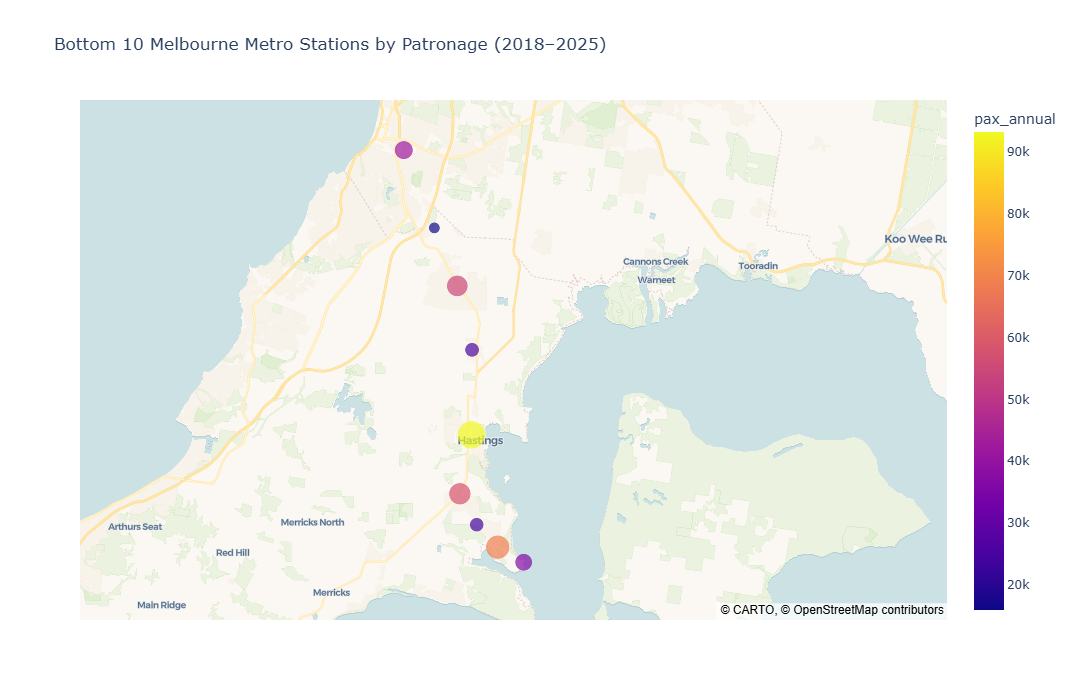

In [46]:
fig = px.scatter_map(
    bottom_10_stations,
    lat="stop_lat",
    lon="stop_long",
    size="pax_annual",
    color="pax_annual",
    hover_name="stop_name",
    hover_data={
        "pax_annual": ":,",
        "stop_lat": False,
        "stop_long": False
    },
    zoom=10,
    height=700,
    title="Bottom 10 Melbourne Metro Stations by Patronage (2018–2025)"
)

fig.show()

### Observation

The lowest-patronage stations are heavily concentrated on the Stony Point corridor in Melbourne's south-east. This suggests that low patronage is not randomly distributed across the network but is associated with specific geographic and service characteristics.

Many of these stations serve low-density residential areas and are located on a branch line with fewer services and lower population catchments than major metropolitan corridors.

### Analysis 5 — COVID Impact

In [48]:
# Calculate network-level COVID impact
pre_covid = network_patronage.loc[
    network_patronage["financial_year"] == "2018-2019",
    "pax_annual"
].iloc[0]

current = network_patronage.loc[
    network_patronage["financial_year"] == "2024-2025",
    "pax_annual"
].iloc[0]

recovery_pct = (current / pre_covid) * 100

print(f"Recovery to pre-COVID level: {recovery_pct:.1f}%")

Recovery to pre-COVID level: 77.1%


### By 2024–2025, network patronage had recovered to 77.1% of pre-pandemic levels.

In [72]:
# Separate pre-COVID and COVID year data

pre_covid_df = (
    master_df[master_df[YEAR_COL] == PRE_COVID_YEAR]
    [[STATION_COL, PATRONAGE_COL]]
    .rename(columns={PATRONAGE_COL: PRE_COVID_YEAR})
)

covid_df = (
    master_df[master_df[YEAR_COL] == COVID_YEAR]
    [[STATION_COL, PATRONAGE_COL]]
    .rename(columns={PATRONAGE_COL: COVID_YEAR})
)

In [73]:
covid_comparison = pd.merge(
    pre_covid_df,
    covid_df,
    on=STATION_COL,
    how="inner"
)

covid_comparison.head()

,stop_name,2018-2019,2020-2021
0,Stony Point,5400,3900
1,Crib Point,17900,8450
2,Morradoo,5650,2200
3,Bittern,14800,5350
4,Hastings,21900,10500


In [74]:
covid_comparison["covid_change"] = (
    covid_comparison[COVID_YEAR]
    - covid_comparison[PRE_COVID_YEAR]
)

covid_comparison["covid_change_pct"] = (
    covid_comparison["covid_change"]
    / covid_comparison[PRE_COVID_YEAR]
    * 100
).round(2)

covid_comparison.tail()

,stop_name,2018-2019,2020-2021,covid_change,covid_change_pct
217,Southern Cross,19551450,4556450,-14995000,-76.70
218,Hughesdale,443900,250500,-193400,-43.57
219,Showgrounds,180000,4150,-175850,-97.69
220,Hawkstowe,193600,70900,-122700,-63.38
221,Mernda,562350,327900,-234450,-41.69


In [75]:
# Calculate absolute and percentage patronage change during COVID

covid_comparison["covid_change"] = (
    covid_comparison[COVID_YEAR]
    - covid_comparison[PRE_COVID_YEAR]
)

covid_comparison["covid_change_pct"] = (
    covid_comparison["covid_change"]
    / covid_comparison[PRE_COVID_YEAR]
    * 100
).round(2)

covid_comparison.head()

,stop_name,2018-2019,2020-2021,covid_change,covid_change_pct
0,Stony Point,5400,3900,-1500,-27.78
1,Crib Point,17900,8450,-9450,-52.79
2,Morradoo,5650,2200,-3450,-61.06
3,Bittern,14800,5350,-9450,-63.85
4,Hastings,21900,10500,-11400,-52.05


In [76]:
# Calculate network-level COVID impact

network_pre_covid = covid_comparison[PRE_COVID_YEAR].sum()
network_covid = covid_comparison[COVID_YEAR].sum()

network_covid_change_pct = (
    (network_covid - network_pre_covid)
    / network_pre_covid
    * 100
).round(2)

network_covid_change_pct

np.float64(-66.4)

In [77]:
covid_comparison.isna().sum()

stop_name           0
2018-2019           0
2020-2021           0
covid_change        0
covid_change_pct    0
dtype: int64

In [78]:
# Identify stations with the largest percentage decline

most_impacted_stations = (
    covid_comparison
    .sort_values("covid_change_pct")
    .head(10)
)

most_impacted_stations[
    [STATION_COL, PRE_COVID_YEAR, COVID_YEAR, "covid_change_pct"]
]

,stop_name,2018-2019,2020-2021,covid_change_pct
219,Showgrounds,180000,4150,-97.69
187,Flemington Racecourse,212350,25350,-88.06
132,Coburg,728500,145500,-80.03
212,Parliament,10124200,2213650,-78.14
91,Aircraft,303150,70150,-76.86
217,Southern Cross,19551450,4556450,-76.70
207,Williams Landing,1756650,411450,-76.58
133,Moreland,380850,91250,-76.04
11,East Malvern,481150,127600,-73.48
161,Diggers Rest,221250,59350,-73.18


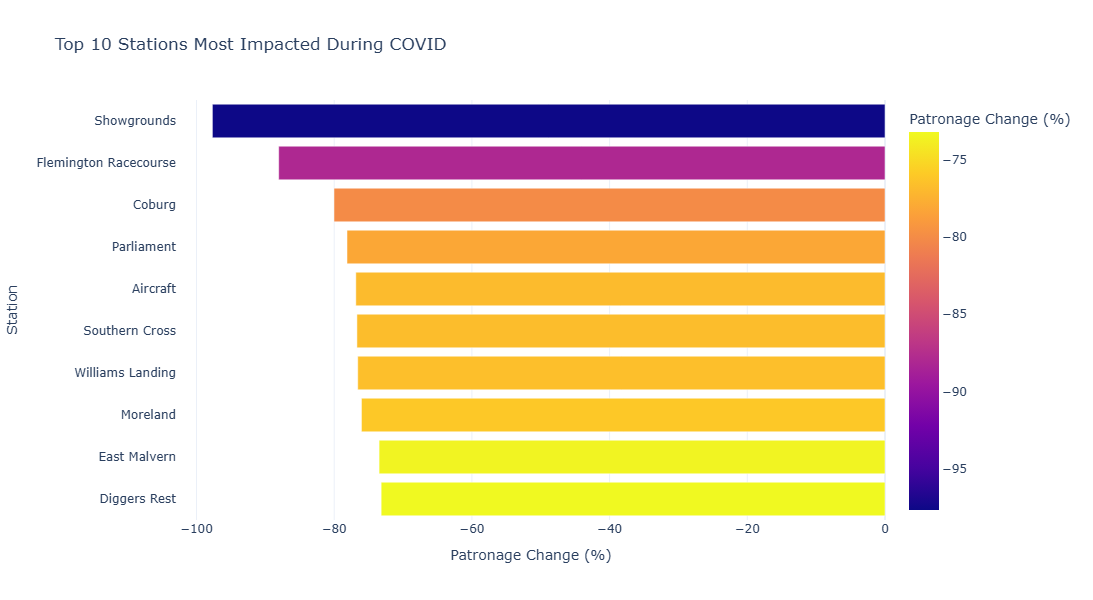

In [79]:
fig = px.bar(
    most_impacted_stations,
    x="covid_change_pct",
    y="stop_name",
    orientation="h",
    color="covid_change_pct",
    title="Top 10 Stations Most Impacted During COVID",
    labels={
        "covid_change_pct": "Patronage Change (%)",
        "stop_name": "Station"
    },
    height=600
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(autorange="reversed")
)

fig.show()

### Observation

The stations most impacted by COVID experienced patronage declines of approximately 75%–95% compared to pre-pandemic levels.

Event-focused stations such as Showgrounds and Flemington Racecourse recorded the largest declines, reflecting the suspension of major public events and gatherings during the pandemic.

Major CBD stations including Parliament and Southern Cross also experienced substantial reductions in patronage, likely driven by widespread adoption of remote working arrangements and reduced commuter travel.

Several commuter-oriented suburban stations also appear among the most affected locations, highlighting the broader impact of reduced workplace attendance across Melbourne's rail network.

### Analysis 6: Weekday vs Weekend Behaviour

In [80]:
# Combine saturday and sunday columns to get weekend patronage columns
master_df_copy = master_df.copy()
master_df_copy["pax_weekend"] = master_df_copy["pax_saturday"] +	master_df_copy["pax_sunday"]
master_df_copy.head()

,financial_year,stop_id,stop_name,stop_lat,stop_long,pax_annual,pax_weekday,pax_norm_weekday,pax_sch_hol_weekday,pax_saturday,pax_sunday,pax_pre_am_peak,pax_am_peak,pax_interpeak,pax_pm_peak,pax_pm_late,pax_weekend
0,2018-2019,19827,Stony Point,-38.374235,145.221837,5400,50,50,50,50,50,50,50,50,50,50,100
1,2018-2019,19828,Crib Point,-38.366123,145.204043,17900,50,50,50,150,100,50,50,50,50,50,250
2,2018-2019,19829,Morradoo,-38.354033,145.189603,5650,50,50,50,50,50,50,50,50,50,50,100
3,2018-2019,19830,Bittern,-38.337390,145.178026,14800,50,50,50,50,50,50,50,50,50,50,100
4,2018-2019,19831,Hastings,-38.305659,145.185980,21900,50,50,50,50,50,50,50,50,50,50,100


In [81]:
# Define weekday and weekend patronage columns
# Define weekday and weekend patronage columns

WEEKDAY_WEEKEND_COLS = [
    "pax_weekday",
    "pax_weekend"
]

master_df_copy[WEEKDAY_WEEKEND_COLS].head()

,pax_weekday,pax_weekend
0,50,100
1,50,250
2,50,100
3,50,100
4,50,100


In [82]:
# Aggregate weekday and weekend patronage by financial year

weekday_weekend_trend = (
    master_df_copy
    .groupby(YEAR_COL)[WEEKDAY_WEEKEND_COLS]
    .sum()
    .reset_index()
)

weekday_weekend_trend

,financial_year,pax_weekday,pax_weekend
0,2018-2019,779700,660150
1,2019-2020,597650,513600
2,2020-2021,246850,274150
3,2021-2022,296250,359150
4,2022-2023,477350,538350
5,2023-2024,560200,593800
6,2024-2025,570400,594500


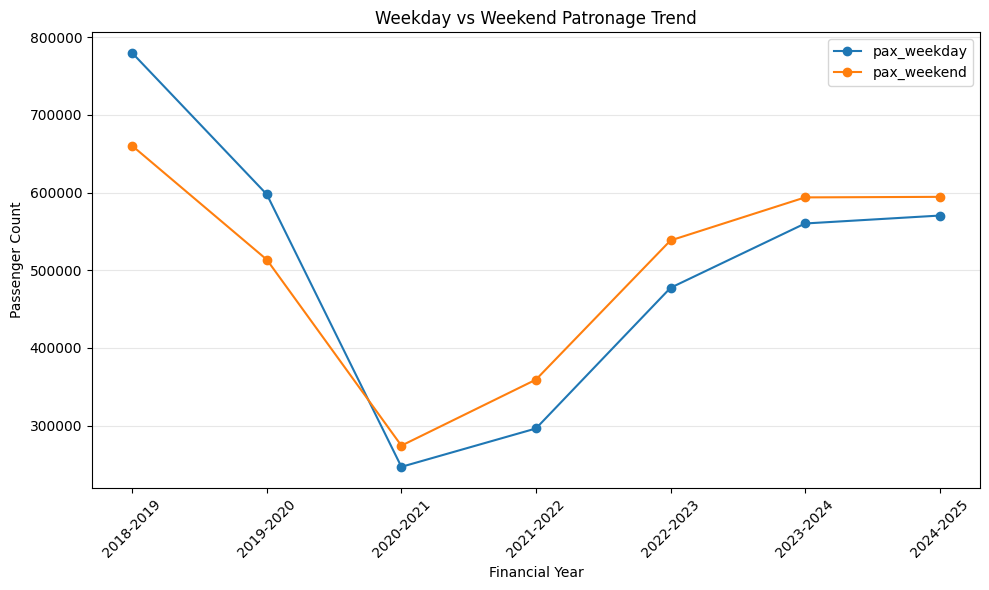

In [90]:
plt.figure(figsize=(10, 6))

for column in WEEKDAY_WEEKEND_COLS:
    plt.plot(
        weekday_weekend_trend[YEAR_COL],
        weekday_weekend_trend[column],
        marker="o",
        label=column
    )

plt.title("Weekday vs Weekend Patronage Trend")
plt.xlabel("Financial Year")
plt.ylabel("Passenger Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

The Melbourne metropolitan rail network experienced a substantial decline in both weekday and weekend patronage during the COVID-19 period, with passenger numbers reaching their lowest levels in 2020–2021.

Prior to COVID, weekday patronage was consistently higher than weekend patronage, reflecting the importance of commuter travel across the network.

During the pandemic, weekday patronage declined more sharply than weekend patronage. As a result, the gap between weekday and weekend travel narrowed considerably.

Following the pandemic, both weekday and weekend patronage recovered steadily. However, weekend patronage recovered faster and exceeded weekday patronage from 2020–2021 onwards.

By 2024–2025, passenger demand had recovered significantly but remained below pre-pandemic levels. Weekend patronage continued to slightly exceed weekday patronage, suggesting that travel patterns may have shifted following the pandemic.

In [85]:
# Calculate weekend share of total weekday/weekend patronage

weekday_weekend_trend["weekday_weekend_total"] = (
    weekday_weekend_trend["pax_weekday"]
    + weekday_weekend_trend["pax_weekend"]
)

weekday_weekend_trend["weekend_share_pct"] = (
    weekday_weekend_trend["pax_weekend"]
    / weekday_weekend_trend["weekday_weekend_total"]
    * 100
)

weekday_weekend_trend[
    [YEAR_COL, "weekend_share_pct"]
].round(2)

,financial_year,weekend_share_pct
0,2018-2019,45.85
1,2019-2020,46.22
2,2020-2021,52.62
3,2021-2022,54.80
4,2022-2023,53.00
5,2023-2024,51.46
6,2024-2025,51.03


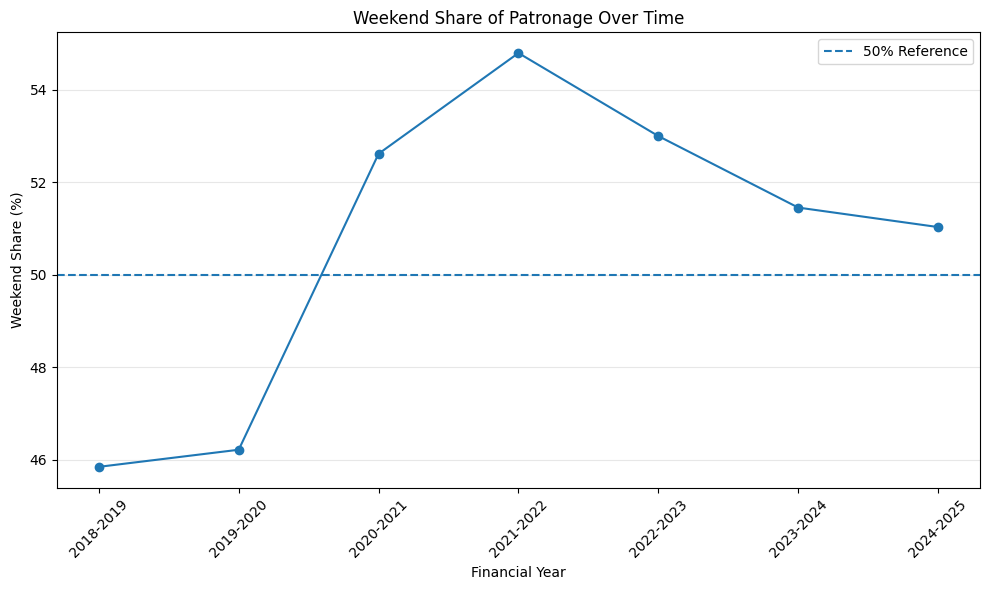

In [89]:
plt.figure(figsize=(10, 6))

plt.plot(
    weekday_weekend_trend["financial_year"],
    weekday_weekend_trend["weekend_share_pct"],
    marker="o"
)

# Reference line
plt.axhline(
    y=50,
    linestyle="--",
    label="50% Reference"
)

plt.title("Weekend Share of Patronage Over Time")
plt.xlabel("Financial Year")
plt.ylabel("Weekend Share (%)")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()

### Observation

Weekend patronage accounted for less than half of weekday/weekend travel before COVID, at approximately 46% in 2018–2019 and 2019–2020.

During the COVID period, weekend share increased above 50%, peaking in 2021–2022. This suggests that weekday commuter travel declined more sharply than weekend travel during the pandemic period.

Although weekend share has gradually reduced since 2021–2022, it remained above pre-COVID levels in 2024–2025, indicating a possible shift in travel behaviour after the pandemic.

### Analysis 7: Station-Level Peak Demand

In [91]:
#  Create peak total column for latest year
station_peak = master_df.copy()
station_peak

,financial_year,stop_id,stop_name,stop_lat,stop_long,pax_annual,pax_weekday,pax_norm_weekday,pax_sch_hol_weekday,pax_saturday,pax_sunday,pax_pre_am_peak,pax_am_peak,pax_interpeak,pax_pm_peak,pax_pm_late
0,2018-2019,19827,Stony Point,-38.374235,145.221837,5400,50,50,50,50,50,50,50,50,50,50
1,2018-2019,19828,Crib Point,-38.366123,145.204043,17900,50,50,50,150,100,50,50,50,50,50
2,2018-2019,19829,Morradoo,-38.354033,145.189603,5650,50,50,50,50,50,50,50,50,50,50
3,2018-2019,19830,Bittern,-38.337390,145.178026,14800,50,50,50,50,50,50,50,50,50,50
4,2018-2019,19831,Hastings,-38.305659,145.185980,21900,50,50,50,50,50,50,50,50,50,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1550,2024-2025,49458,East Pakenham,-38.084284,145.506311,54500,150,150,100,200,200,50,50,50,50,50
1551,2024-2025,52095,Southland,-37.958758,145.049124,479000,1350,1300,1500,1400,1100,50,250,450,500,100
1552,2024-2025,52159,Middle Gorge,-37.644062,145.092140,222950,750,850,500,300,200,100,350,100,250,50
1553,2024-2025,52160,Hawkstowe,-37.622992,145.097396,208500,700,750,550,350,200,150,400,100,50,50


In [92]:
station_peak["pax_total_peak"] = (
    station_peak["pax_am_peak"]
    + station_peak["pax_pm_peak"]
)
station_peak.head()

,financial_year,stop_id,stop_name,stop_lat,stop_long,pax_annual,pax_weekday,pax_norm_weekday,pax_sch_hol_weekday,pax_saturday,pax_sunday,pax_pre_am_peak,pax_am_peak,pax_interpeak,pax_pm_peak,pax_pm_late,pax_total_peak
0,2018-2019,19827,Stony Point,-38.374235,145.221837,5400,50,50,50,50,50,50,50,50,50,50,100
1,2018-2019,19828,Crib Point,-38.366123,145.204043,17900,50,50,50,150,100,50,50,50,50,50,100
2,2018-2019,19829,Morradoo,-38.354033,145.189603,5650,50,50,50,50,50,50,50,50,50,50,100
3,2018-2019,19830,Bittern,-38.337390,145.178026,14800,50,50,50,50,50,50,50,50,50,50,100
4,2018-2019,19831,Hastings,-38.305659,145.185980,21900,50,50,50,50,50,50,50,50,50,50,100


In [95]:
top_peak_stations = (
    station_peak.groupby("stop_name")["pax_total_peak"]
    .sum()
    .reset_index()
    .sort_values("pax_total_peak", ascending=False)
    .head(10)
)
top_peak_stations

,stop_name,pax_total_peak
71,Flinders Street,249100
186,Southern Cross,206150
123,Melbourne Central,137950
159,Parliament,111700
68,Flagstaff,61200
72,Footscray,55500
185,South Yarra,46050
35,Caulfield,35650
24,Box Hill,33250
166,Richmond,31200


In [96]:
station_peak["pax_total_peak"].describe()

count     1555.000000
mean      1519.774920
std       3895.635731
min        100.000000
25%        400.000000
50%        750.000000
75%       1375.000000
max      60100.000000
Name: pax_total_peak, dtype: float64

In [97]:
station_peak["pax_am_peak"].describe()

count    1555.000000
mean      650.225080
std       620.850406
min        50.000000
25%       250.000000
50%       500.000000
75%       850.000000
max      5400.000000
Name: pax_am_peak, dtype: float64

In [98]:
(station_peak["pax_am_peak"] == 50).sum()

np.int64(107)

In [99]:
(station_peak["pax_total_peak"] == 100).sum()

np.int64(98)

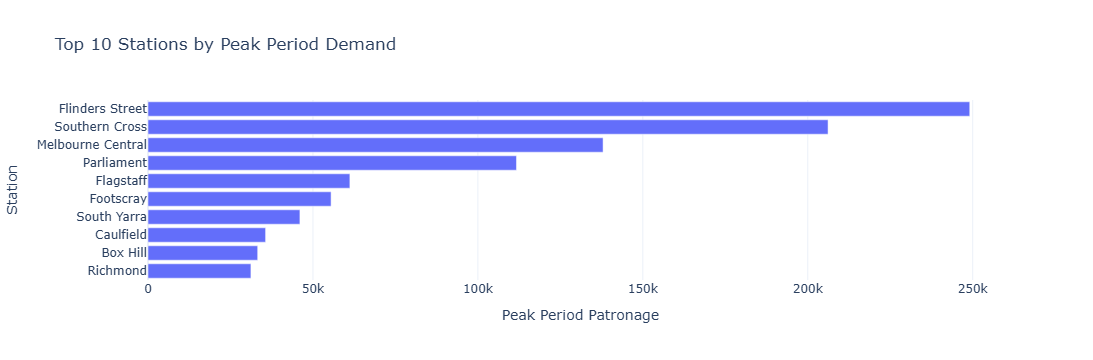

In [103]:
fig = px.bar(
    top_peak_stations,
    x="pax_total_peak",
    y="stop_name",
    orientation="h",
    title="Top 10 Stations by Peak Period Demand",
    labels={
        "pax_total_peak": "Peak Period Patronage",
        "stop_name": "Station"
    }
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(autorange="reversed")
)

fig.show()

### Observation

Flinders Street recorded the highest peak-period patronage across the study period, followed by Southern Cross and Melbourne Central.

The results are dominated by Melbourne CBD stations, indicating that commuter demand remains highly concentrated around the city centre. Major interchange stations such as Southern Cross and Footscray also rank highly, reflecting their role as key transfer hubs within the metropolitan rail network.

Several activity-centre stations including Box Hill, Caulfield, Richmond and South Yarra appear in the top ten, suggesting that both employment destinations and interchange opportunities significantly influence peak-period demand.

### Business Insight

Peak-period demand is concentrated in a relatively small number of stations. This suggests that capacity planning, platform management, passenger flow optimisation and future infrastructure investment should continue to focus on CBD stations and major interchange locations where crowding pressures are likely to be greatest.

## Conclusion

This analysis examined Melbourne metropolitan train station patronage between FY2018–19 and FY2024–25 to understand network demand patterns, the impact of COVID-19, and post-pandemic recovery trends.

Key findings include:

- Network patronage declined significantly during the COVID-19 period, reaching its lowest level in FY2020–21 before recovering steadily in subsequent years.
- Despite strong recovery, total network patronage in FY2024–25 remained below pre-pandemic levels, suggesting that travel demand has not fully returned to historical levels.
- CBD and interchange stations, including Flinders Street, Southern Cross, Melbourne Central, and Parliament, consistently recorded the highest passenger volumes and peak-period demand.
- Passenger demand is highly concentrated geographically, with the busiest stations clustered around Melbourne's CBD and major activity centres.
- The lowest-demand stations were predominantly located on outer suburban and branch-line corridors, particularly along the Stony Point line, indicating the influence of population density and network connectivity on station utilisation.
- Weekend travel proved more resilient than weekday travel during the pandemic, and weekend patronage remained slightly stronger relative to weekday patronage in the post-pandemic period, suggesting possible long-term changes in travel behaviour.
- Peak-period demand analysis showed that a relatively small number of stations account for a large proportion of network activity, highlighting areas where capacity planning and operational improvements may have the greatest impact.

### Business Recommendations

Based on these findings, transport planners and network operators should:

1. Continue monitoring post-pandemic travel behaviour to determine whether hybrid working patterns are creating permanent shifts in demand.
2. Prioritise capacity planning and infrastructure investment at CBD stations and major interchange hubs where passenger volumes remain concentrated.
3. Investigate opportunities to improve service attractiveness and accessibility on lower-utilisation corridors.
4. Incorporate changing weekday and weekend travel patterns into future timetable planning and service optimisation initiatives.

Overall, the analysis demonstrates that Melbourne's rail network has experienced substantial recovery since the pandemic; however, passenger demand patterns continue to evolve, creating both challenges and opportunities for future transport planning.